# Importing Required Libraries
pandas – Data loading and DataFrame manipulation  
numpy – Numerical and array operations  
matplotlib – Data visualization and plotting  
seaborn – Statistical data visualization  
train_test_split – Splitting data into training and testing sets  
LinearRegression – Linear regression model  
DecisionTreeRegressor – Decision tree regression model  
RandomForestRegressor – Multiple decision trees for regression  
GradientBoostingRegressor – Sequential boosting regression model  
ExtraTreesRegressor – Randomized decision tree regression model  
mean_absolute_error – Measures average absolute prediction error  
mean_squared_error – Measures average squared prediction error  
r2_score – Measures how well the model fits the data  
GroupShuffleSplit – Splits Data while maintaining groups

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.model_selection import GroupShuffleSplit

# Loading the Dataset

The original World Cup dataset is loaded from the raw data folder. The raw
dataset is kept unchanged so that the original data is preserved throughout
the project.

In [2]:
df = pd.read_csv("../data/raw/world_cup_score.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


# Data Exploration(head)
It prints the first five rows of dataset

In [4]:
df.head()

,Year,Match Number,City,Date,Winner,Team 1,Team 2,Total Score for Team 1,Total Wicket for Team 1,Total Score for Team 2,Total Wicket for Team 2,Batting team,Bowling team,Over Number,Runs Scored in over,Runs Scored till that over,Wicket Taken in over,Wickets Taken till that over,Winning Details,Match Detail
0,2023,1st Match (D/N),Ahmedabad,October 05 2023,New Zealand,ENG,NZ,282,9,283,1,ENG,NZ,1,12,12,0,0,New Zealand won by 9 wickets (with 82 balls re...,"1st Match (D/N), Ahmedabad, October 05, 2023,\..."
1,2023,1st Match (D/N),Ahmedabad,October 05 2023,New Zealand,ENG,NZ,282,9,283,1,ENG,NZ,2,0,12,0,0,New Zealand won by 9 wickets (with 82 balls re...,"1st Match (D/N), Ahmedabad, October 05, 2023,\..."
2,2023,1st Match (D/N),Ahmedabad,October 05 2023,New Zealand,ENG,NZ,282,9,283,1,ENG,NZ,3,4,16,0,0,New Zealand won by 9 wickets (with 82 balls re...,"1st Match (D/N), Ahmedabad, October 05, 2023,\..."
3,2023,1st Match (D/N),Ahmedabad,October 05 2023,New Zealand,ENG,NZ,282,9,283,1,ENG,NZ,4,5,21,0,0,New Zealand won by 9 wickets (with 82 balls re...,"1st Match (D/N), Ahmedabad, October 05, 2023,\..."
4,2023,1st Match (D/N),Ahmedabad,October 05 2023,New Zealand,ENG,NZ,282,9,283,1,ENG,NZ,5,5,26,0,0,New Zealand won by 9 wickets (with 82 balls re...,"1st Match (D/N), Ahmedabad, October 05, 2023,\..."


The `info()` function is used to examine the structure of the dataset,
including the number of records, columns, data types, and non-null values.
This helps us understand the dataset before performing preprocessing.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21031 entries, 0 to 21030
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   Year                          21031 non-null  int64
 1   Match Number                  21031 non-null  str  
 2   City                          21031 non-null  str  
 3   Date                          21031 non-null  str  
 4   Winner                        21031 non-null  str  
 5   Team 1                        21031 non-null  str  
 6   Team 2                        21031 non-null  str  
 7   Total Score for Team 1        21031 non-null  int64
 8   Total Wicket for Team 1       21031 non-null  int64
 9   Total Score for Team 2        21031 non-null  int64
 10  Total Wicket for Team 2       21031 non-null  int64
 11  Batting team                  21031 non-null  str  
 12  Bowling team                  21031 non-null  str  
 13  Over Number                   21031 non-nu

The `describe()` function provides statistical summaries of numerical
variables, including count, mean, standard deviation, minimum, maximum,
and quartile values.

In [6]:
df.describe()

,Year,Total Score for Team 1,Total Wicket for Team 1,Total Score for Team 2,Total Wicket for Team 2,Over Number,Runs Scored in over,Runs Scored till that over,Wicket Taken in over,Wickets Taken till that over
count,21031.000000,21031.000000,21031.000000,21031.000000,21031.000000,21031.000000,21031.000000,21031.000000,21031.000000,21031.000000
mean,2014.932290,271.296039,7.921639,217.018306,7.210737,23.391470,5.376492,116.560506,0.169749,3.004232
std,5.694119,72.797107,2.022988,62.168418,3.215083,13.800212,3.835236,79.200010,0.411207,2.400196
min,2007.000000,58.000000,1.000000,55.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2011.000000,221.000000,6.000000,177.000000,4.000000,12.000000,3.000000,52.000000,0.000000,1.000000
50%,2015.000000,275.000000,8.000000,215.000000,9.000000,23.000000,5.000000,106.000000,0.000000,3.000000
75%,2019.000000,327.000000,10.000000,261.000000,10.000000,35.000000,7.000000,168.000000,0.000000,4.000000
max,2023.000000,428.000000,10.000000,383.000000,10.000000,50.000000,36.000000,428.000000,4.000000,10.000000


# Checking Missing Values
The `isnull().sum()` function calculates the number of missing values
present in each column.

In [7]:
df.isnull().sum()

Year                            0
Match Number                    0
City                            0
Date                            0
Winner                          0
Team 1                          0
Team 2                          0
Total Score for Team 1          0
Total Wicket for Team 1         0
Total Score for Team 2          0
Total Wicket for Team 2         0
Batting team                    0
Bowling team                    0
Over Number                     0
Runs Scored in over             0
Runs Scored till that over      0
Wicket Taken in over            0
Wickets Taken till that over    0
Winning Details                 0
Match Detail                    0
dtype: int64

# Checking Duplicate Records
The 'duplicated()' function identifies duplicate rows, and `sum()' counts
the total number of duplicate records.

In [8]:
df.duplicated().sum()

np.int64(0)

# Exploring Dataset Variables

The columns of the dataset are examined to distinguish numerical and
categorical variables.
- `df.select_dtypes(include=np.number)' – Selects columns containing numerical data.
- `.columns.tolist()' – Converts the column names into a list.
- `df.select_dtypes(include="str")' – Selects columns containing string/categorical data.

In [11]:
print("Numerical columns:")
print(df.select_dtypes(include=np.number).columns.tolist())

print("\nCategorical columns:")
print(df.select_dtypes(include="str").columns.tolist())

Numerical columns:
['Year', 'Total Score for Team 1', 'Total Wicket for Team 1', 'Total Score for Team 2', 'Total Wicket for Team 2', 'Over Number', 'Runs Scored in over', 'Runs Scored till that over', 'Wicket Taken in over', 'Wickets Taken till that over']

Categorical columns:
['Match Number', 'City', 'Date', 'Winner', 'Team 1', 'Team 2', 'Batting team', 'Bowling team', 'Winning Details', 'Match Detail']


# Creating the Target Variable

The target variable for this regression problem is `final_score'.

`final_score' represents the final score of the team that batted first in
each match. The first batting team is identified using the order of the
batting-team records within each match.

- `groupby(["Year", "Match Number"])' – Groups rows belonging to the same match.
- `transform("first")' – Finds the first batting team in each match.
- `first_batting_team' – Stores the team that batted first.
- `np.where()' – Selects the final score based on which team batted first.

In [ ]:
first_batting_team = df.groupby(
    ["Year", "Match Number"]
)["Batting team"].transform("first")

df["final_score"] = np.where(
    first_batting_team == df["Team 1"],
    df["Total Score for Team 1"],
    df["Total Score for Team 2"]
)

print(df[[
    "Year",
    "Match Number",
    "Team 1",
    "Team 2",
    "Batting team",
    "final_score"
]].head(20))

    Year     Match Number Team 1 Team 2 Batting team  final_score
0   2023  1st Match (D/N)    ENG     NZ          ENG          282
1   2023  1st Match (D/N)    ENG     NZ          ENG          282
2   2023  1st Match (D/N)    ENG     NZ          ENG          282
3   2023  1st Match (D/N)    ENG     NZ          ENG          282
4   2023  1st Match (D/N)    ENG     NZ          ENG          282
5   2023  1st Match (D/N)    ENG     NZ          ENG          282
6   2023  1st Match (D/N)    ENG     NZ          ENG          282
7   2023  1st Match (D/N)    ENG     NZ          ENG          282
8   2023  1st Match (D/N)    ENG     NZ          ENG          282
9   2023  1st Match (D/N)    ENG     NZ          ENG          282
10  2023  1st Match (D/N)    ENG     NZ          ENG          282
11  2023  1st Match (D/N)    ENG     NZ          ENG          282
12  2023  1st Match (D/N)    ENG     NZ          ENG          282
13  2023  1st Match (D/N)    ENG     NZ          ENG          282
14  2023  

# Verifying the Target Variable

The target variable is checked to ensure that it contains valid final scores
and does not contain missing values. This confirms that the target is ready
for machine learning.

In [14]:
print("Missing final_score values:", df["final_score"].isnull().sum())
print("\nFinal score statistics:")
print(df["final_score"].describe())

Missing final_score values: 0

Final score statistics:
count    21031.000000
mean       271.296039
std         72.797107
min         58.000000
25%        221.000000
50%        275.000000
75%        327.000000
max        428.000000
Name: final_score, dtype: float64


# Feature Selection

We select the important columns needed to predict the final score.
Columns that contain the final score or match result are not used as features
because they can cause data leakage.

# Separating Features and Target

The independent variables are stored in 'X', while the target variable
'final_score' is stored in 'y'. This separation prepares the dataset for
preprocessing and model training.

In [ ]:
features = [
    "Year",
    "City",
    "Team 1",
    "Team 2",
    "Batting team",
    "Bowling team",
    "Over Number",
    "Runs Scored in over",
    "Runs Scored till that over",
    "Wicket Taken in over",
    "Wickets Taken till that over"
]

X= df[features]
y = df["final_score"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['Year', 'City', 'Team 1', 'Team 2', 'Batting team', 'Bowling team', 'Over Number', 'Runs Scored in over', 'Runs Scored till that over', 'Wicket Taken in over', 'Wickets Taken till that over']

Target:
final_score


In [16]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (21031, 11)
y shape: (21031,)


# Encoding Categorical Data

Machine Learning models need numerical values, so the categorical columns
are converted into numerical values using one-hot encoding.

pd.get_dummies() converts categorical columns into numerical columns.

columns specifies the categorical columns that need to be converted.

dtype=int converts the values into 0 and 1.

X.shape shows the number of rows and columns after encoding.


In [ ]:
X = pd.get_dummies(X, columns=["City","Team 1","Team 2","Batting team",
"Bowling team"], dtype=int)

print("Shape after encoding:", X.shape)

Shape after encoding: (21031, 121)


# Checking Encoded Data

The encoded dataset is checked to confirm that the categorical columns have
been converted into numerical columns.

In [18]:
print(X.head())
print("\nData types:")
print(X.dtypes)

   Year  Over Number  Runs Scored in over  Runs Scored till that over  \
0  2023            1                   12                          12   
1  2023            2                    0                          12   
2  2023            3                    4                          16   
3  2023            4                    5                          21   
4  2023            5                    5                          26   

   Wicket Taken in over  Wickets Taken till that over  City_ Adelaide  \
0                     0                             0               0   
1                     0                             0               0   
2                     0                             0               0   
3                     0                             0               0   
4                     0                             0               0   

   City_ Ahmedabad  City_ Auckland  City_ Bengaluru  ...  Bowling team_KENYA  \
0                1               0        

In [82]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

## Splitting Data by Match

The dataset contains multiple rows for each match. Therefore, rows from the
same match should not be present in both training and testing data.

We split the data by match so that the testing data contains completely
unseen matches.

Group-based Train-Test Split 
groups creates a unique group for each match using Year and Match Number.

GroupShuffleSplit divides the data into training and testing sets based on matches.

n_splits=1 means only one train-test split is created.

test_size=0.2 means 20% of the groups are used for testing and 80% for training.

random_state=42 keeps the same split every time the code is run.

gss.split() generates the training and testing indices.

iloc – Used to select rows or columns from a DataFrame using their integer position (index number).


X_train and y_train contain the training data.

X_test and y_test contain the testing data.

X_train.shape and X_test.shape show the number of rows and columns in the input data.

y_train.shape and y_test.shape show the number of target values.

In [32]:
groups = df["Year"].astype(str) + "_" + df["Match Number"].astype(str)

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (16870, 121)
X_test: (4161, 121)
y_train: (16870,)
y_test: (4161,)


# Building Regression Models

Three regression models are trained to predict the final score.
The models are Linear Regression, Decision Tree Regression, and
Random Forest Regression.
fit() = model learns the relationship between X_train and y_train.

In [34]:
linear_model = LinearRegression()
tree_model = DecisionTreeRegressor(random_state=42)
forest_model = RandomForestRegressor(
    n_estimators=10,
    random_state=42
)
linear_model.fit(X_train, y_train)
tree_model.fit(X_train, y_train)
forest_model.fit(X_train, y_train)

print("All three models trained successfully.")

All three models trained successfully.


# Evaluating the Models

The trained models are evaluated using MAE, MSE, RMSE, and R² score.
These metrics are used to measure and compare the prediction performance
of the three regression models.

In [ ]:
# Predictions
linear_pred = linear_model.predict(X_test)
tree_pred = tree_model.predict(X_test)
forest_pred = forest_model.predict(X_test)

def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(name)
    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R²  :", r2)
    print()

evaluate_model("Linear Regression", y_test, linear_pred)
evaluate_model("Decision Tree", y_test, tree_pred)
evaluate_model("Random Forest", y_test, forest_pred)

Linear Regression
MAE : 53.26518713994249
MSE : 4231.852517821649
RMSE: 65.05269031962973
R²  : 0.12433336436864206

Decision Tree
MAE : 70.366258111031
MSE : 8343.572698870465
RMSE: 91.34315901516908
R²  : -0.7264751556432827

Random Forest
MAE : 63.30706560922855
MSE : 6550.710898822399
RMSE: 80.93646210962275
R²  : -0.35549122981209536



# Additional Regression Models

Additional tree-based regression models are trained to check whether they
can perform better than the models already tested.

In [36]:

gradient_model = GradientBoostingRegressor(random_state=42)
extra_model = ExtraTreesRegressor(
    n_estimators=25,
    random_state=42
)

gradient_model.fit(X_train, y_train)
extra_model.fit(X_train, y_train)

print("Additional models trained successfully.")

Additional models trained successfully.


# Evaluating Additional Models

The additional regression models are evaluated using the same metrics as
the previous models so that their performance can be compared fairly.

In [37]:
gradient_pred = gradient_model.predict(X_test)
extra_pred = extra_model.predict(X_test)

evaluate_model("Gradient Boosting", y_test, gradient_pred)
evaluate_model("Extra Trees", y_test, extra_pred)

Gradient Boosting
MAE : 46.83772198943344
MSE : 3591.73417899167
RMSE: 59.93107857357207
R²  : 0.2567884227168745

Extra Trees
MAE : 58.087277096851714
MSE : 5807.6148637346805
RMSE: 76.20770868970331
R²  : -0.2017277415393013



# Feature Engineering

We create a few useful features from the existing data to improve prediction.

In [38]:
df["Current Run Rate"] = (
    df["Runs Scored till that over"] / df["Over Number"]
)

df["Remaining Overs"] = 50 - df["Over Number"]

df[[
    "Over Number",
    "Runs Scored till that over",
    "Current Run Rate",
    "Remaining Overs"
]].head()

,Over Number,Runs Scored till that over,Current Run Rate,Remaining Overs
0,1,12,12.000000,49
1,2,12,6.000000,48
2,3,16,5.333333,47
3,4,21,5.250000,46
4,5,26,5.200000,45


# Updating Features

The newly created features are added to the input data so they can be used
by the machine learning models.

In [39]:
X = df[[
    "Year",
    "City",
    "Team 1",
    "Team 2",
    "Batting team",
    "Bowling team",
    "Over Number",
    "Runs Scored in over",
    "Runs Scored till that over",
    "Wicket Taken in over",
    "Wickets Taken till that over",
    "Current Run Rate",
    "Remaining Overs"
]]

y = df["final_score"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (21031, 13)
y shape: (21031,)


# Encoding
cat.codes assigns a numerical code to each category.

In [43]:
categorical_columns = [
    "City",
    "Team 1",
    "Team 2",
    "Batting team",
    "Bowling team"
]

for column in categorical_columns:
    X[column] = X[column].astype("category").cat.codes

print(X.dtypes)

Year                              int64
City                               int8
Team 1                             int8
Team 2                             int8
Batting team                       int8
Bowling team                       int8
Over Number                       int64
Runs Scored in over               int64
Runs Scored till that over        int64
Wicket Taken in over              int64
Wickets Taken till that over      int64
Current Run Rate                float64
Remaining Overs                   int64
dtype: object


# Splitting Data by Match

The data is split by match so that the same match does not appear in both
training and testing data.

In [97]:
groups = df["Year"].astype(str) + "_" + df["Match Number"].astype(str)

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (16870, 13)
X_test: (4161, 13)
y_train: (16870,)
y_test: (4161,)


# Training Regression Models

The regression models are trained using the updated 13 features.

In [98]:
linear_model = LinearRegression()
tree_model = DecisionTreeRegressor(random_state=42)
forest_model = RandomForestRegressor(n_estimators=100, random_state=42)
gradient_model = GradientBoostingRegressor(random_state=42)
extra_model = ExtraTreesRegressor(n_estimators=100, random_state=42)

linear_model.fit(X_train, y_train)
tree_model.fit(X_train, y_train)
forest_model.fit(X_train, y_train)
gradient_model.fit(X_train, y_train)
extra_model.fit(X_train, y_train)

print("All models trained successfully.")

All models trained successfully.


# Evaluating Regression Models

The trained models are evaluated using MAE, MSE, RMSE, and R².
These metrics help us compare the prediction performance of each model.

In [99]:
# Predictions
linear_pred = linear_model.predict(X_test)
tree_pred = tree_model.predict(X_test)
forest_pred = forest_model.predict(X_test)
gradient_pred = gradient_model.predict(X_test)
extra_pred = extra_model.predict(X_test)

# Store models and predictions
model_results = [
    ("Linear Regression", linear_pred),
    ("Decision Tree", tree_pred),
    ("Random Forest", forest_pred),
    ("Gradient Boosting", gradient_pred),
    ("Extra Trees", extra_pred)
]
for name, predictions in model_results:

    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    print(name)
    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R²  :", r2)
    print("-" * 40)

Linear Regression
MAE : 47.25713139802956
MSE : 3701.128944780586
RMSE: 60.83690446415388
R²  : 0.23415215500417774
----------------------------------------
Decision Tree
MAE : 69.11006969478491
MSE : 7808.067051189618
RMSE: 88.36326754477574
R²  : -0.6156668448877707
----------------------------------------
Random Forest
MAE : 51.365066089882234
MSE : 4457.660069646719
RMSE: 66.76571028339862
R²  : 0.07760864076967389
----------------------------------------
Gradient Boosting
MAE : 45.79779657815067
MSE : 3447.6835602742717
RMSE: 58.716978466830795
R²  : 0.28659577543572834
----------------------------------------
Extra Trees
MAE : 43.640257149723624
MSE : 3337.3160421773614
RMSE: 57.769507892809344
R²  : 0.30943332774831533
----------------------------------------


# Selecting the Best Model

Extra Trees is selected as the final model because it achieved the lowest MAE
and RMSE and the highest R² among the tested models.

In [52]:
best_model = extra_model

print("Selected Model: Extra Trees")

Selected Model: Extra Trees


# Sample Prediction on Unseen Data

A sample from the test dataset is given to the selected Extra Trees model.
The predicted final score is compared with the actual final score.

X_test.iloc[[0]] selects the first row from the test data as a sample.

y_test.iloc[0] gets the actual score of that sample.

best_model.predict(sample) uses the trained best model to predict the score.

[0] gets the predicted value from the prediction result.

In [106]:
for i in range(5):
    sample = X_test.iloc[[i]]
    actual_score = y_test.iloc[i]
    predicted_score = best_model.predict(sample)[0]
    print("Sample", i + 1)
    print("Actual Final Score:", actual_score)
    print("Predicted Final Score:", round(predicted_score, 2))
    print("-" * 30)

Sample 1
Actual Final Score: 286
Predicted Final Score: 284.7
------------------------------
Sample 2
Actual Final Score: 286
Predicted Final Score: 287.53
------------------------------
Sample 3
Actual Final Score: 286
Predicted Final Score: 285.58
------------------------------
Sample 4
Actual Final Score: 286
Predicted Final Score: 283.04
------------------------------
Sample 5
Actual Final Score: 286
Predicted Final Score: 285.61
------------------------------


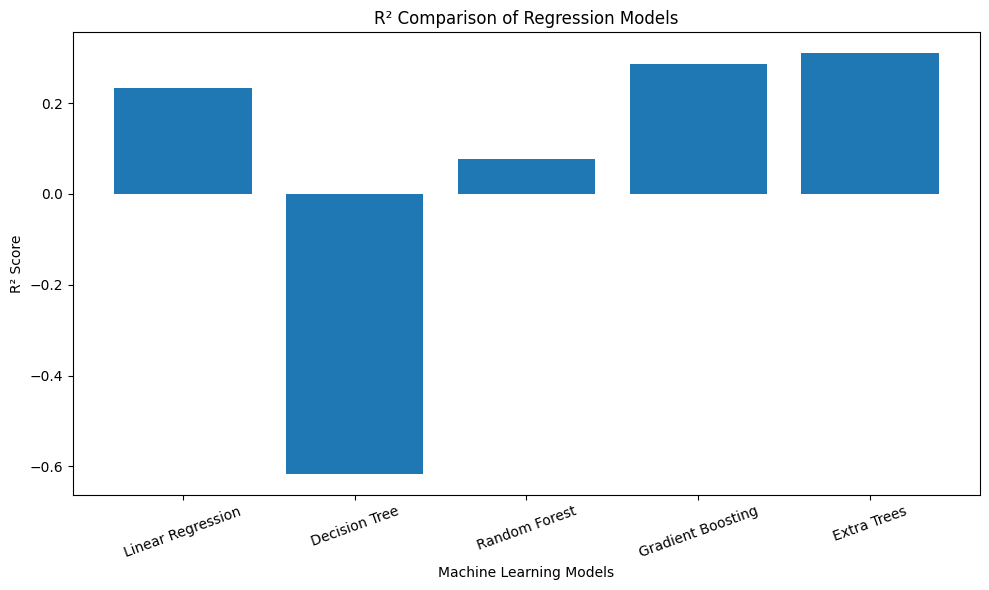

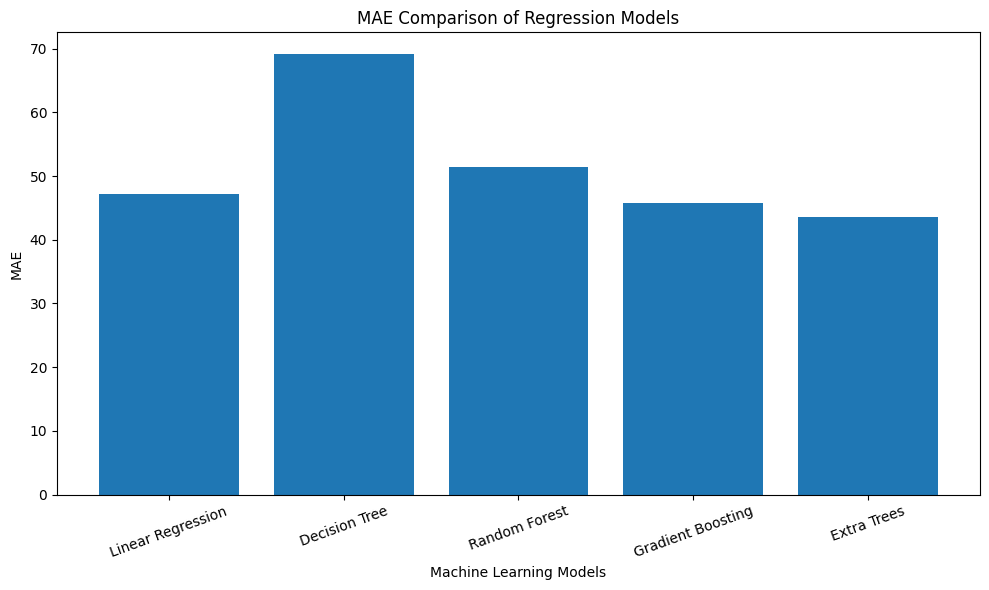

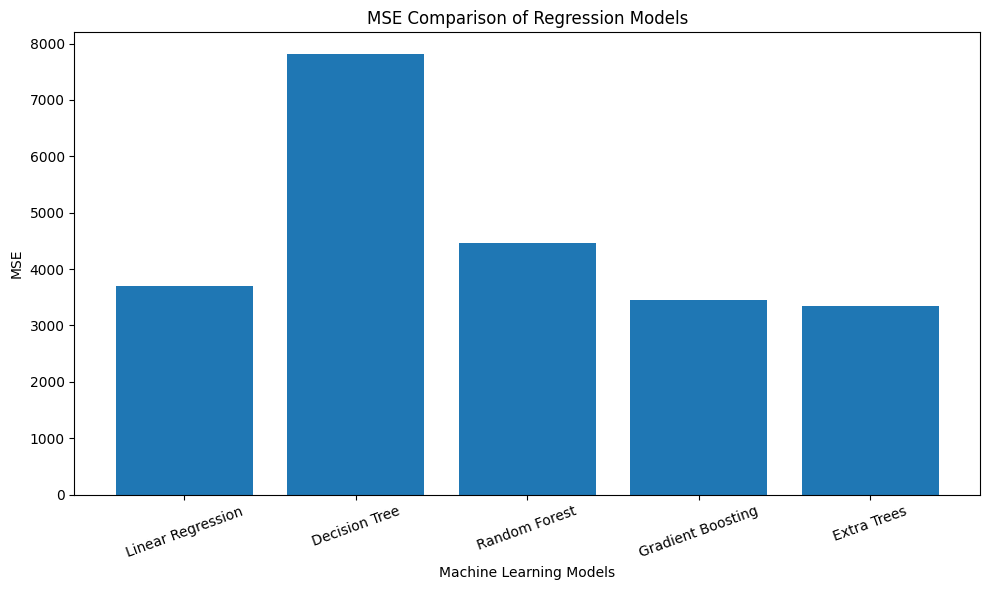

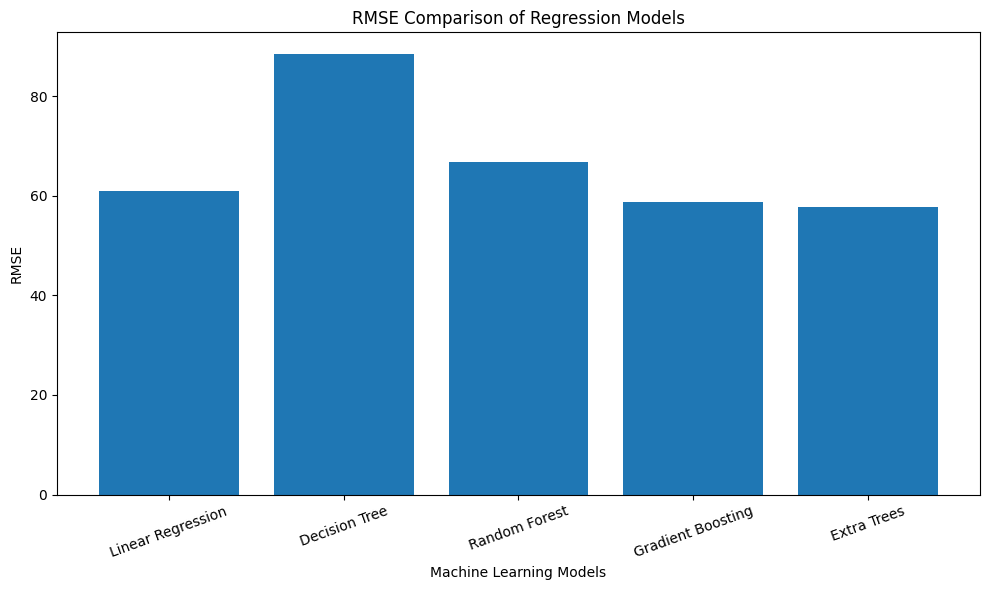

All 4 comparison graphs saved successfully!


In [109]:
import os
os.makedirs("../outputs", exist_ok=True)

models = [
    "Linear Regression",
    "Decision Tree",
    "Random Forest",
    "Gradient Boosting",
    "Extra Trees"
]

mae = [
    47.25713139802956,
    69.11006969478491,
    51.365066089882234,
    45.79779657815067,
    43.640257149723624
]

mse = [
    3701.128944780586,
    7808.067051189618,
    4457.660069646719,
    3447.6835602742717,
    3337.3160421773614
]

rmse = [
    60.83690446415388,
    88.36326754477574,
    66.76571028339862,
    58.716978466830795,
    57.769507892809344
]

r2 = [
    0.23415215500417774,
    -0.6156668448877707,
    0.07760864076967389,
    0.28659577543572834,
    0.30943332774831533
]

plt.figure(figsize=(10, 6))
plt.bar(models, r2)
plt.xlabel("Machine Learning Models")
plt.ylabel("R² Score")
plt.title("R² Comparison of Regression Models")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("../outputs/r2comp.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 6))
plt.bar(models, mae)
plt.xlabel("Machine Learning Models")
plt.ylabel("MAE")
plt.title("MAE Comparison of Regression Models")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("../outputs/maecomp.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 6))
plt.bar(models, mse)
plt.xlabel("Machine Learning Models")
plt.ylabel("MSE")
plt.title("MSE Comparison of Regression Models")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("../outputs/msecomp.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 6))
plt.bar(models, rmse)
plt.xlabel("Machine Learning Models")
plt.ylabel("RMSE")
plt.title("RMSE Comparison of Regression Models")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("../outputs/rmsecomp.png", dpi=300, bbox_inches="tight")
plt.show()

print("All 4 comparison graphs saved successfully!")

# Saving the Best Model

The selected Extra Trees model is saved so that it can be reused later
without training the model again.

In [73]:
import joblib

joblib.dump(best_model, "../models/extra_trees_model.pkl")

print("Model saved successfully.")

Model saved successfully.


In [56]:
df.to_csv("../data/processed/processed_data.csv", index=False)

print("Processed dataset saved successfully.")

Processed dataset saved successfully.


# Saving Model Comparison Results

The evaluation results of all regression models are saved for comparison
and future reference.

In [57]:
results = {
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "Extra Trees"
    ],
    "MAE": [
        47.2571,
        69.1101,
        51.3651,
        45.7978,
        43.6403
    ],
    "MSE": [
        3701.1289,
        7808.0671,
        4457.6601,
        3447.6836,
        3337.3160
    ],
    "RMSE": [
        60.8369,
        88.3633,
        66.7657,
        58.7170,
        57.7695
    ],
    "R2": [
        0.2342,
        -0.6157,
        0.0776,
        0.2866,
        0.3094
    ]
}

results_df = pd.DataFrame(results)

results_df.to_csv("../outputs/model_comparison.csv", index=False)

print("Model comparison saved successfully.")

Model comparison saved successfully.


# Saving Sample Prediction

The actual and predicted scores from the unseen test sample are saved
for future reference.

In [58]:
prediction_result = pd.DataFrame({
    "Actual Score": [286],
    "Predicted Score": [284.7]
})

prediction_result.to_csv(
    "../outputs/sample_prediction.csv",
    index=False
)

print("Sample prediction saved successfully.")

Sample prediction saved successfully.


# Conclusion

In this project, machine learning models were used to predict the final
batting score in ICC Men's Cricket World Cup matches.

The dataset was checked for missing values and duplicate records. Categorical
features were converted into numerical values, and useful features such as
Current Run Rate and Remaining Overs were created.

Five regression models were trained and compared: Linear Regression, Decision
Tree, Random Forest, Gradient Boosting, and Extra Trees.

Extra Trees performed best among the tested models with an MAE of 43.64,
RMSE of 57.77, and R² of 0.309.

Therefore, Extra Trees was selected as the final model. A sample prediction
on unseen test data predicted 284.7 runs compared with the actual score of
286 runs.